https://arxiv.org/pdf/2303.12077

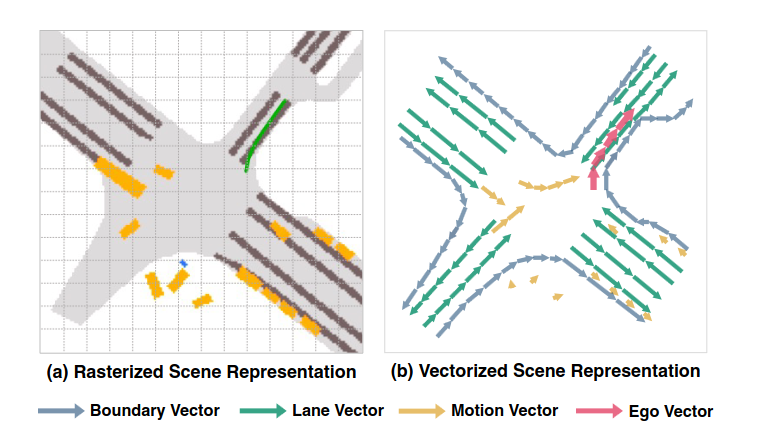  

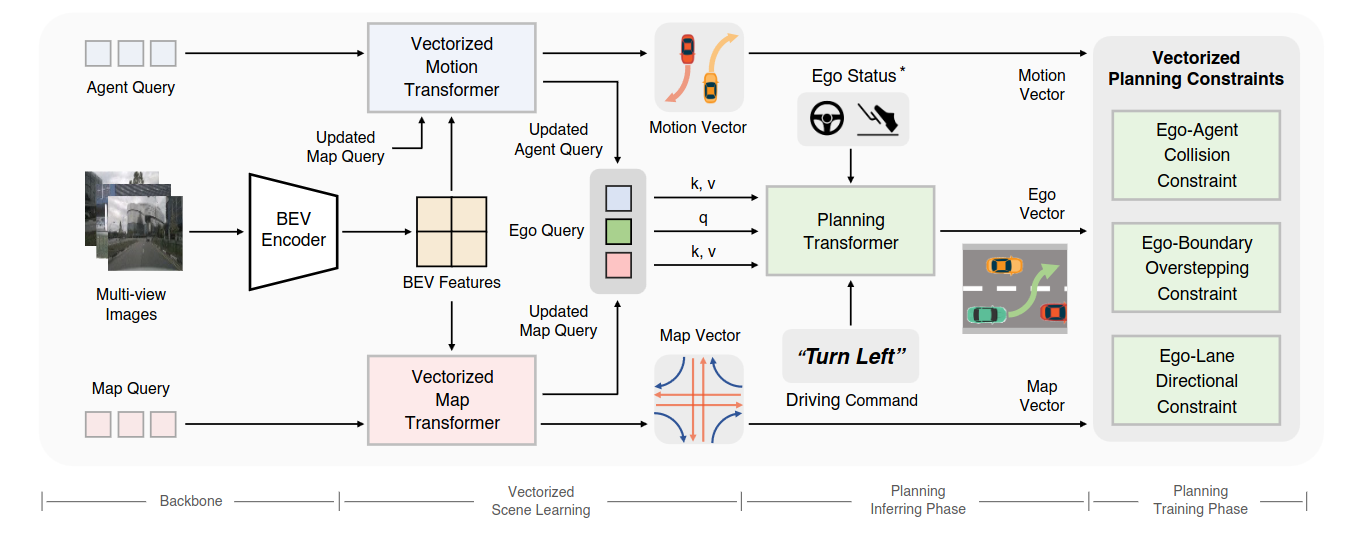

# VAD: Vectorized Scene Representation for Efficient Autonomous Driving 论文详解

## 一、论文概况与核心思想

这篇题为 **《VAD: Vectorized Scene Representation for Efficient Autonomous Driving》** 的论文发表于 ICCV 2023，由华中科技大学和地平线机器人联合提出。其核心思想是：

- 提出一种**完全向量化的端到端自动驾驶范式**，将驾驶场景建模为**向量化地图**和**向量化智能体运动**，摒弃了以往依赖密集栅格化表示（如语义地图、占用图、流场图、代价图）的方法。
- 向量化表示具有两个关键优势：
  1. **实例级结构信息**：地图向量（车道、边界）和运动向量（其他车辆的未来轨迹）提供了明确的规划约束，显著提升安全性。
  2. **计算高效**：稀疏向量表示避免了密集栅格图的计算开销和后处理步骤，推理速度大幅提升。
- 在 nuScenes 基准上，VAD 以更快的速度取得了领先的规划性能，证明了向量化范式在端到端自动驾驶中的潜力。

---

## 二、背景与动机

### 2.1 自动驾驶场景表示的演变

自动驾驶系统需要理解周围环境以进行安全规划。传统方法将感知和规划解耦，存在信息损失和误差累积问题。端到端方法虽然统一了框架，但大多数工作仍然使用**栅格化场景表示**：

- 语义地图：将 BEV 空间划分为网格，每个网格标注类别。
- 占用图：预测未来每个网格是否被占用。
- 流场图：预测未来每个网格的运动矢量。
- 代价图：为不同区域赋予代价，用于路径搜索。

**问题**：栅格化表示计算密集（需要处理大量网格），且丢失了实例级结构信息（例如，无法区分两辆相邻车辆是两辆车还是一个整体，也无法获取精确的车道方向）。此外，许多方法还需要手工设计的后处理步骤（如基于代价图的最优轨迹搜索），这些步骤的鲁棒性和泛化性较差。

### 2.2 向量化表示的动机

与栅格化相比，向量化表示具有天然优势：

- **地图元素**（车道中心线、道路边界、人行横道）可以表示为折线（polyline）或曲线，这些向量直接提供了道路结构信息，如车道方向、可行驶边界，有助于缩小轨迹搜索空间。
- **动态智能体**的未来运动可以表示为多条轨迹向量（多模态），这些向量提供了实例级的碰撞避免约束。
- 向量化表示是**稀疏的**，计算量远小于密集栅格，更利于实时部署。

因此，VAD 旨在构建一个完全向量化的端到端框架，同时实现高性能和高效率。

---

## 三、方法详解

### 3.1 总体架构

VAD 的框架如图 2 所示，分为四个阶段：

1. **骨干网络 + BEV 编码器**：将多帧多视角图像转换为 BEV 特征。
2. **向量化场景学习**：使用智能体查询和地图查询从 BEV 特征中学习向量化地图和向量化智能体运动。
3. **规划（推理阶段）**：通过自车查询与智能体查询、地图查询交互，输出规划轨迹。
4. **向量化规划约束（训练阶段）**：利用显式的向量化场景表示（运动向量、地图向量）对规划轨迹施加实例级约束。

### 3.2 向量化场景学习

#### 3.2.1 向量化地图

- 使用一组**地图查询** $ Q_m $（可学习嵌入），通过可变形注意力从 BEV 特征图中提取地图信息。
- 每个地图查询预测一个地图向量 $ \hat{V}_m \in \mathbb{R}^{N_m \times N_p \times 2} $（$ N_m $ 个地图元素，每个包含 $ N_p $ 个点）及其类别分数。
- 考虑三类地图元素：**车道分隔线**（提供方向信息）、**道路边界**（界定可行驶区域）、**人行横道**。
- 地图查询和地图向量在后续规划中分别提供隐式特征和显式约束。

#### 3.2.2 向量化智能体运动

- 使用一组**智能体查询** $ Q_a $，通过可变形注意力从 BEV 特征中提取智能体特征。
- 解码智能体的属性（位置、类别分数、朝向、尺寸等）。
- 进行**智能体-智能体**和**智能体-地图**交互（类似 PIP 的设计），以丰富智能体特征用于运动预测。
- 输出每个智能体的**多模态未来轨迹** $ \hat{V}_a \in \mathbb{R}^{N_a \times N_k \times T_f \times 2} $（$ N_a $ 个智能体，每个 $ N_k $ 种模态，预测 $ T_f $ 个未来时刻），并为每种模态输出一个概率分数。
- 运动向量用于后续的碰撞约束，智能体查询则作为场景信息传递给规划模块。

### 3.3 基于交互的规划

VAD 使用一个随机初始化的**自车查询** $ Q_{ego} $ 来提取对规划有价值的隐式场景特征。

#### 3.3.1 自车-智能体交互

自车查询首先与智能体查询交互，以了解其他动态交通参与者的位置和运动意图。使用 Transformer 解码器，自车查询作为 query，智能体查询作为 key/value。位置编码通过 MLP 将预测的自车位置 $ p_{ego} $ 和智能体位置 $ p_a $ 编码为位置嵌入，以提供相对位置信息。

#### 3.3.2 自车-地图交互

更新后的自车查询进一步与地图查询交互，获取静态道路结构信息。同样使用 Transformer 解码器，但使用不同的 MLP 对地图元素位置进行编码。

经过两次交互后，自车查询 $ Q''_{ego} $ 融合了动态和静态场景信息。

#### 3.3.3 规划头

- VAD 是无高清地图的规划，需要高层驾驶命令（左转、右转、直行）作为导航输入。
- 规划头输入：更新后的自车查询（$ Q'_{ego}, Q''_{ego} $）、可选的自车状态 $ s_{ego} $、驾驶命令嵌入 $ c $。
- 输出：未来 $ T_f $ 个时刻的规划轨迹 $ \hat{V}_{ego} \in \mathbb{R}^{T_f \times 2} $。
- 规划头是一个简单的 MLP。

### 3.4 向量化规划约束

在训练阶段，VAD 利用显式的向量化场景表示对规划轨迹施加三种实例级约束，以提高安全性。这些约束是可微的，且计算开销很小。

#### 3.4.1 自车-智能体碰撞约束

- 目的：保持自车与其他动态智能体在纵向和横向上的安全距离。
- 方法：首先过滤低置信度的智能体预测（阈值 $ \epsilon_a $），多模态预测中选取置信度最高的轨迹作为最终预测。对于每个未来时间步，在横向（X）和纵向（Y）方向上分别找到距离最近的智能体，如果距离小于阈值 $ \delta_X $ 或 $ \delta_Y $，则惩罚差值。
- 纵向和横向采用不同的阈值（例如 $ \delta_X=1.5m, \delta_Y=3.0m $），因为纵向需要更长的安全距离。
- 损失：$ L_{col} = \frac{1}{T_f}\sum_{t=1}^{T_f}\sum_{i \in \{X,Y\}} L_i^{t} $，其中 $ L_i^{t} = \max(0, \delta_i - d_i^{t}) $。

#### 3.4.2 自车-边界越界约束

- 目的：将规划轨迹限制在可行驶区域内，避免压线或驶出道路。
- 方法：对每个未来时间步，计算规划路径点与最近的道路边界线的距离 $ d_{bd}^t $，如果小于阈值 $ \delta_{bd} $（默认 1.0m），则惩罚差值。
- 损失：$ L_{bd} = \frac{1}{T_f}\sum_{t=1}^{T_f} \max(0, \delta_{bd} - d_{bd}^t) $。

#### 3.4.3 自车-车道方向约束

- 目的：使规划轨迹的运动方向与所在车道的方向一致，避免逆行或大幅偏离车道方向。
- 方法：在每个未来时间步，找到距离规划路径点最近的车道分隔线向量（在一定范围内），计算车道向量与自车运动向量（从上一时刻到当前时刻的向量）之间的角度差，取平均。
- 损失：$ L_{dir} = \frac{1}{T_f}\sum_{t=1}^{T_f} \text{Fang}(\hat{v}_m^t, \hat{v}_{ego}^t) $，其中 $ \hat{v}_{ego}^t $ 是自车向量。

### 3.5 端到端训练

总损失为各项损失的加权和：

$$
\mathcal{L} = \omega_1 \mathcal{L}_{map} + \omega_2 \mathcal{L}_{mot} + \omega_3 \mathcal{L}_{col} + \omega_4 \mathcal{L}_{bd} + \omega_5 \mathcal{L}_{dir} + \omega_6 \mathcal{L}_{imi}
$$

- **地图损失** $ \mathcal{L}_{map} $：曼哈顿距离回归损失 + Focal 分类损失。
- **运动预测损失** $ \mathcal{L}_{mot} $：智能体属性回归（L1）、类别 Focal 损失、多模态轨迹回归（选择 minFDE 的模态计算 L1）和多模态分类 Focal 损失。
- **碰撞/边界/方向约束损失**：如上所述。
- **模仿学习损失** $ \mathcal{L}_{imi} $：规划轨迹与真值轨迹的 L1 损失。

VAD 完全端到端可微，无需后处理。

---

## 四、实验与结果

### 4.1 实验设置

- **数据集**：nuScenes，1000 个场景，每个约 20 秒，6 相机覆盖 360°。
- **输入**：2 秒历史信息，规划 3 秒未来轨迹（$ T_f=6 $）。
- **模型变体**：
  - **VAD-Base**：BEV 查询 200×200，地图查询 100×20，智能体查询 300，ResNet50 骨干，输入分辨率 1280×720。
  - **VAD-Tiny**：BEV 查询 100×100，层数减半，输入分辨率 640×360。
- **训练**：8 块 RTX 3090，60 epochs，AdamW + Cosine Annealing。
- **指标**：开环用位移误差（DE）和碰撞率（CR）；闭环用 CARLA Town05 的 Driving Score (DS) 和 Route Completion (RC)。

### 4.2 主要结果

#### 开环规划（nuScenes）

- **性能**：VAD-Base 将平均 L2 误差从 UniAD 的 1.03m 降至 **0.72m**（降低 30.1%），平均碰撞率从 0.31% 降至 **0.22%**（降低 29.0%）。
- **速度**：VAD-Base 推理 FPS 为 **4.5**（UniAD 为 1.8），VAD-Tiny 达到 **16.8 FPS**（9.3× 加速），同时保持可比的规划性能（L2 0.78m，碰撞率 0.38%）。
- 即使与 LiDAR 方法相比，VAD 也更具优势（如 FF、EO）。

#### 闭环规划（CARLA）

- Town05 Short：VAD-Base DS 64.29，超过 ST-P3（55.14）和 Transfuser（54.52，LiDAR 方法）。
- Town05 Long：VAD-Base DS 30.31，RC 75.20，虽然 DS 低于 ST-P3 的 11.45，但 RC 大幅提升；与 LiDAR 方法 Transfuser 相比，DS 接近（30.31 vs 33.15），RC 更高（75.20 vs 56.36）。

### 4.3 消融研究

- **设计选择**（表 2）：移除自车-地图交互或自车-智能体交互都会导致性能下降；三种向量化约束各自都能降低碰撞率，三者结合效果最佳。
- **栅格化 vs 向量化地图**（表 3）：使用栅格化地图分割的 VAD 变体碰撞率显著更高（0.39% vs 0.22%），证明向量化表示对规划安全性的重要性。
- **模块运行时间**（表 5）：骨干网络和 BEV 编码器占大部分时间，规划模块仅需 3.4ms，体现了向量化表示的高效性。

### 4.4 定性结果

图 4 展示了 VAD 在直行、左转、避让行人等场景中的规划结果，显示其能准确预测多模态智能体运动和向量化地图，并输出合理的规划轨迹。

---

## 五、创新点与贡献总结

1. **首个完全向量化的端到端自动驾驶框架**：将场景表示为向量化地图和向量化智能体运动，摆脱了密集栅格表示和手工后处理。
2. **隐式与显式双重利用向量化信息**：通过查询交互隐式提取场景特征，通过三种实例级规划约束显式利用向量化信息提升安全性。
3. **显著提升性能与效率**：在 nuScenes 上以更快的速度超越 UniAD，碰撞率降低 29%，速度提升 2.5×；轻量版 VAD-Tiny 速度提升 9.3× 且性能可接受。
4. **可部署性**：简洁的模型设计和稀疏表示使得 VAD 易于在车载芯片上部署，为实际应用提供了有价值的参考。

---

## 六、局限性与未来方向

论文在结论中提到了两个值得探索的方向：

- **多模态运动预测的利用**：VAD 在碰撞约束中仅使用置信度最高的模态，如何更有效地利用多模态预测来提高规划安全性值得进一步研究。
- **更多交通信息的融合**：如何将车道图、路标、交通灯、限速等信息整合到系统中，有待探索。

此外，VAD 的开环评测存在一定局限性（如未完全避免捷径学习），闭环评测仅在 CARLA 仿真中进行，尚未在真实车辆上验证。

---

## 七、总结

VAD 通过完全向量化的场景表示，成功地在端到端自动驾驶中兼顾了性能和效率。其核心思想——利用实例级向量信息作为规划约束——不仅提升了安全性，还大幅减少了计算开销，为后续工作（如 VADv2、SparseDrive 等）奠定了重要基础。VAD 证明了向量化范式在自动驾驶中的巨大潜力，推动了行业对稀疏表示和高效规划的探索。